# 05 — Clustering

  Apply K-Means, GMM, and HDBSCAN to all three embedding types. Evaluate and compare using silhouette,
  Davies-Bouldin, Calinski-Harabasz, and topic coherence.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_dir / "arxiv_clean.csv")
df["published"] = pd.to_datetime(df["published"])

tfidf_cluster = np.load(processed_dir / "tfidf_umap_cluster.npy")
minilm_cluster = np.load(processed_dir / "minilm_umap_cluster.npy")
kalm_cluster = np.load(processed_dir / "kalm_umap_cluster.npy")

tfidf_umap2 = np.load(processed_dir / "tfidf_umap2.npy")
minilm_umap2 = np.load(processed_dir / "minilm_umap2.npy")
kalm_umap2 = np.load(processed_dir / "kalm_umap2.npy")

embeddings = {
    "TF-IDF": tfidf_cluster,
    "MiniLM": minilm_cluster,
    "KaLM": kalm_cluster,
}

viz_2d = {
    "TF-IDF": tfidf_umap2,
    "MiniLM": minilm_umap2,
    "KaLM": kalm_umap2,
}

print(f"Papers: {len(df):,}")
print(f"Clustering vectors: {tfidf_cluster.shape[1]}d")

Papers: 181,294
Clustering vectors: 40d


## K-Means — Elbow Method and Silhouette


--- TF-IDF ---
  k=5...
  k=10...
  k=15...
  k=20...
  k=25...
  k=30...
  k=35...
  k=40...
  k=45...
  k=50...

--- MiniLM ---
  k=5...
  k=10...
  k=15...
  k=20...
  k=25...
  k=30...
  k=35...
  k=40...
  k=45...
  k=50...

--- KaLM ---
  k=5...
  k=10...
  k=15...
  k=20...
  k=25...
  k=30...
  k=35...
  k=40...
  k=45...
  k=50...


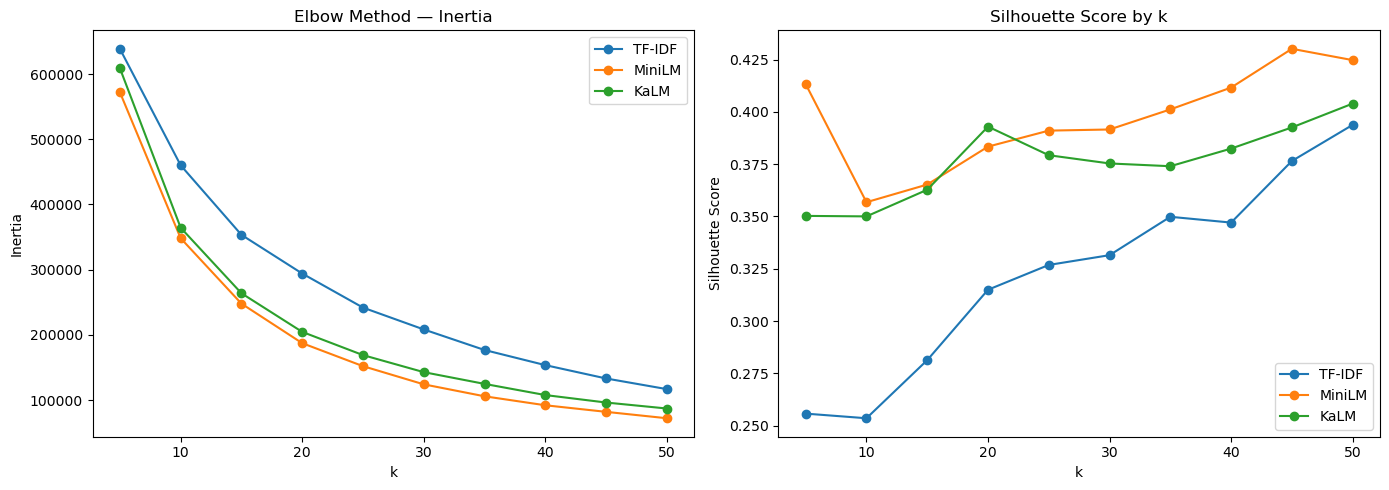

In [3]:
k_range = range(5, 55, 5)

results = {}
for name, data in embeddings.items():
    print(f"\n--- {name} ---")
    inertias = []
    silhouettes = []
    for k in k_range:
        print(f"  k={k}...")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(data, labels, sample_size=10000))
    results[name] = {
        "inertias": inertias,
        "silhouettes": silhouettes,
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    axes[0].plot(list(k_range), res["inertias"], "o-", label=name)
    axes[1].plot(list(k_range), res["silhouettes"], "o-", label=name)

axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method — Inertia")
axes[0].legend()

axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
axes[1].legend()

plt.tight_layout()
fig.savefig(figures_dir / "kmeans_elbow.png", dpi=300, bbox_inches="tight")
plt.show()

### Fine-grained k Search


--- TF-IDF ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...

--- MiniLM ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...

--- KaLM ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...


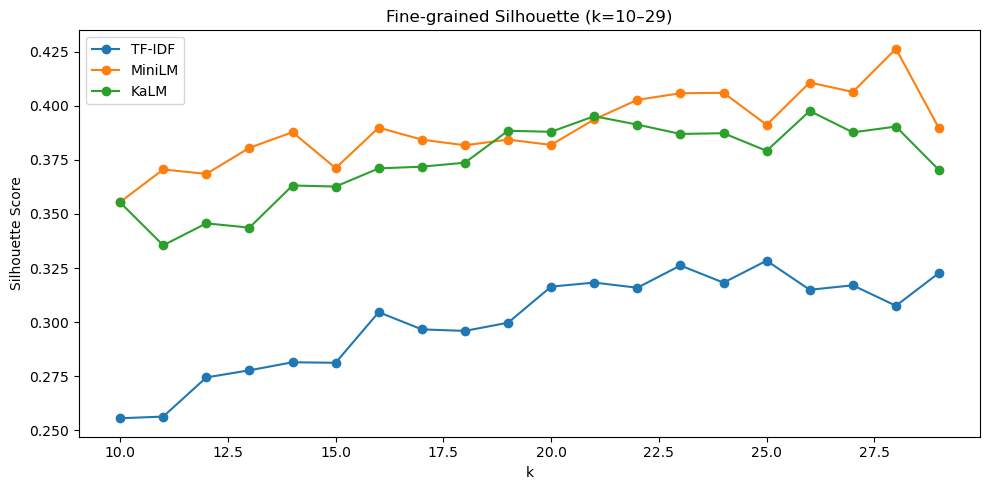

TF-IDF: best k=25, silhouette=0.3284
MiniLM: best k=28, silhouette=0.4263
KaLM: best k=26, silhouette=0.3976


In [4]:
k_fine = range(10, 30)

results_fine = {}
for name, data in embeddings.items():
    print(f"\n--- {name} ---")
    silhouettes = []
    for k in k_fine:
        print(f"  k={k}...")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        silhouettes.append(silhouette_score(data, labels, sample_size=10000))
    results_fine[name] = silhouettes

fig, ax = plt.subplots(figsize=(10, 5))
for name, sils in results_fine.items():
    ax.plot(list(k_fine), sils, "o-", label=name)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Fine-grained Silhouette (k=10–29)")
ax.legend()
plt.tight_layout()
fig.savefig(figures_dir / "kmeans_fine_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

for name, sils in results_fine.items():
    best_idx = np.argmax(sils)
    best_k = list(k_fine)[best_idx]
    print(f"{name}: best k={best_k}, silhouette={sils[best_idx]:.4f}")

## GMM — Silhouette Sweep


--- TF-IDF ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...
  k=30...

--- MiniLM ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...
  k=30...

--- KaLM ---
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...
  k=21...
  k=22...
  k=23...
  k=24...
  k=25...
  k=26...
  k=27...
  k=28...
  k=29...
  k=30...


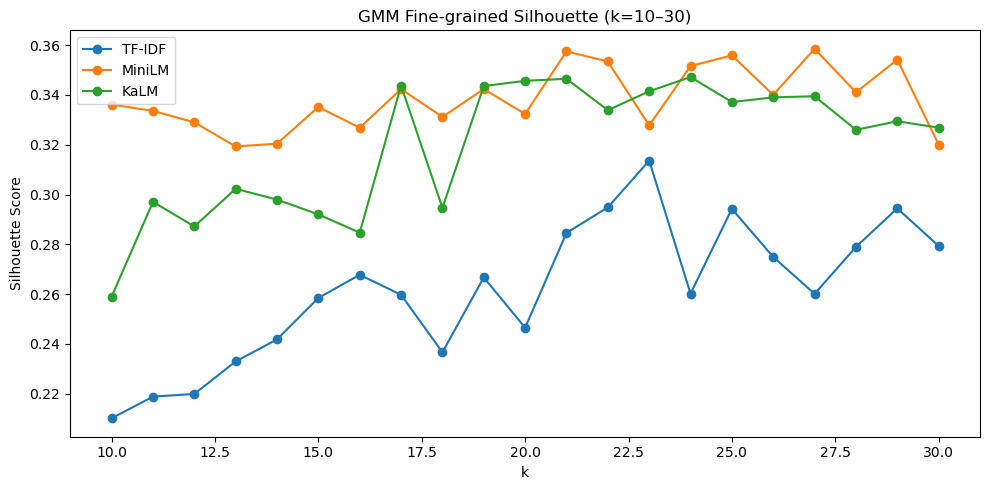

TF-IDF: best k=23, silhouette=0.3136
MiniLM: best k=27, silhouette=0.3585
KaLM: best k=24, silhouette=0.3472


In [5]:
from sklearn.mixture import GaussianMixture

k_fine_gmm = range(10, 31)

gmm_fine = {}
for name, data in embeddings.items():
    print(f"\n--- {name} ---")
    silhouettes = []
    for k in k_fine_gmm:
        print(f"  k={k}...")
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
        labels = gmm.fit_predict(data)
        silhouettes.append(silhouette_score(data, labels, sample_size=10000))
    gmm_fine[name] = silhouettes

fig, ax = plt.subplots(figsize=(10, 5))
for name, sils in gmm_fine.items():
    ax.plot(list(k_fine_gmm), sils, "o-", label=name)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("GMM Fine-grained Silhouette (k=10–30)")
ax.legend()
plt.tight_layout()
fig.savefig(figures_dir / "gmm_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

for name, sils in gmm_fine.items():
    best_idx = np.argmax(sils)
    best_k = list(k_fine_gmm)[best_idx]
    print(f"{name}: best k={best_k}, silhouette={sils[best_idx]:.4f}")

## HDBSCAN — min_cluster_size Sweep

In [6]:
import hdbscan

min_sizes = [100, 500, 1000, 2000]

hdbscan_results = {}
for name, data in embeddings.items():
    print(f"\n--- {name} ---")
    for ms in min_sizes:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=ms,
            min_samples=10,
            metric="euclidean",
        )
        labels = clusterer.fit_predict(data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = (labels == -1).sum()
        noise_pct = noise / len(labels) * 100

        mask = labels != -1
        if len(set(labels[mask])) > 1:
            sil = silhouette_score(data[mask], labels[mask], sample_size=10000)
        else:
            sil = -1

        hdbscan_results[(name, ms)] = {
            "labels": labels,
            "n_clusters": n_clusters,
            "noise_pct": noise_pct,
            "silhouette": sil,
        }

        print(
            f"  min_size={ms}: {n_clusters} clusters, "
            f"{noise:,} noise ({noise_pct:.1f}%), "
            f"silhouette={sil:.4f}"
        )


--- TF-IDF ---
  min_size=100: 290 clusters, 57,924 noise (32.0%), silhouette=0.6498
  min_size=500: 84 clusters, 68,560 noise (37.8%), silhouette=0.5450
  min_size=1000: 42 clusters, 83,415 noise (46.0%), silhouette=0.5170
  min_size=2000: 3 clusters, 16,514 noise (9.1%), silhouette=0.1980

--- MiniLM ---
  min_size=100: 278 clusters, 68,018 noise (37.5%), silhouette=0.5370
  min_size=500: 63 clusters, 57,985 noise (32.0%), silhouette=0.4454
  min_size=1000: 40 clusters, 59,747 noise (33.0%), silhouette=0.4337
  min_size=2000: 6 clusters, 9,659 noise (5.3%), silhouette=-0.0164

--- KaLM ---
  min_size=100: 314 clusters, 66,205 noise (36.5%), silhouette=0.5517
  min_size=500: 73 clusters, 57,396 noise (31.7%), silhouette=0.5024
  min_size=1000: 39 clusters, 64,649 noise (35.7%), silhouette=0.4898
  min_size=2000: 18 clusters, 59,531 noise (32.8%), silhouette=0.3761


## Final Fits

  **K-Means:** TF-IDF k=23, MiniLM k=28, KaLM k=26
  **GMM:** TF-IDF k=23, MiniLM k=29, KaLM k=28
  **HDBSCAN:** min_cluster_size=1000 for all

In [2]:
best_k = {"TF-IDF": 23, "MiniLM": 28, "KaLM": 26}

kmeans_labels = {}
for name, data in embeddings.items():
    k = best_k[name]
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels[name] = km.fit_predict(data)
    print(f"K-Means {name}: k={k}, fitted.")

K-Means TF-IDF: k=23, fitted.
K-Means MiniLM: k=28, fitted.
K-Means KaLM: k=26, fitted.


In [3]:
from sklearn.mixture import GaussianMixture

gmm_best_k = {"TF-IDF": 23, "MiniLM": 29, "KaLM": 28}

gmm_labels = {}
for name, data in embeddings.items():
    k = gmm_best_k[name]
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm_labels[name] = gmm.fit_predict(data)
    print(f"GMM {name}: k={k}, fitted.")

GMM TF-IDF: k=23, fitted.
GMM MiniLM: k=29, fitted.
GMM KaLM: k=28, fitted.


In [4]:
import hdbscan

hdbscan_labels = {}
for name, data in embeddings.items():
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=1000,
        min_samples=10,
        metric="euclidean",
    )
    hdbscan_labels[name] = clusterer.fit_predict(data)
    n_clusters = len(set(hdbscan_labels[name])) - 1
    noise_pct = (hdbscan_labels[name] == -1).mean() * 100
    print(f"HDBSCAN {name}: {n_clusters} clusters, {noise_pct:.1f}% noise")

HDBSCAN TF-IDF: 42 clusters, 46.0% noise
HDBSCAN MiniLM: 40 clusters, 33.0% noise
HDBSCAN KaLM: 39 clusters, 35.7% noise


  ### Cluster Visualizations (2D UMAP)

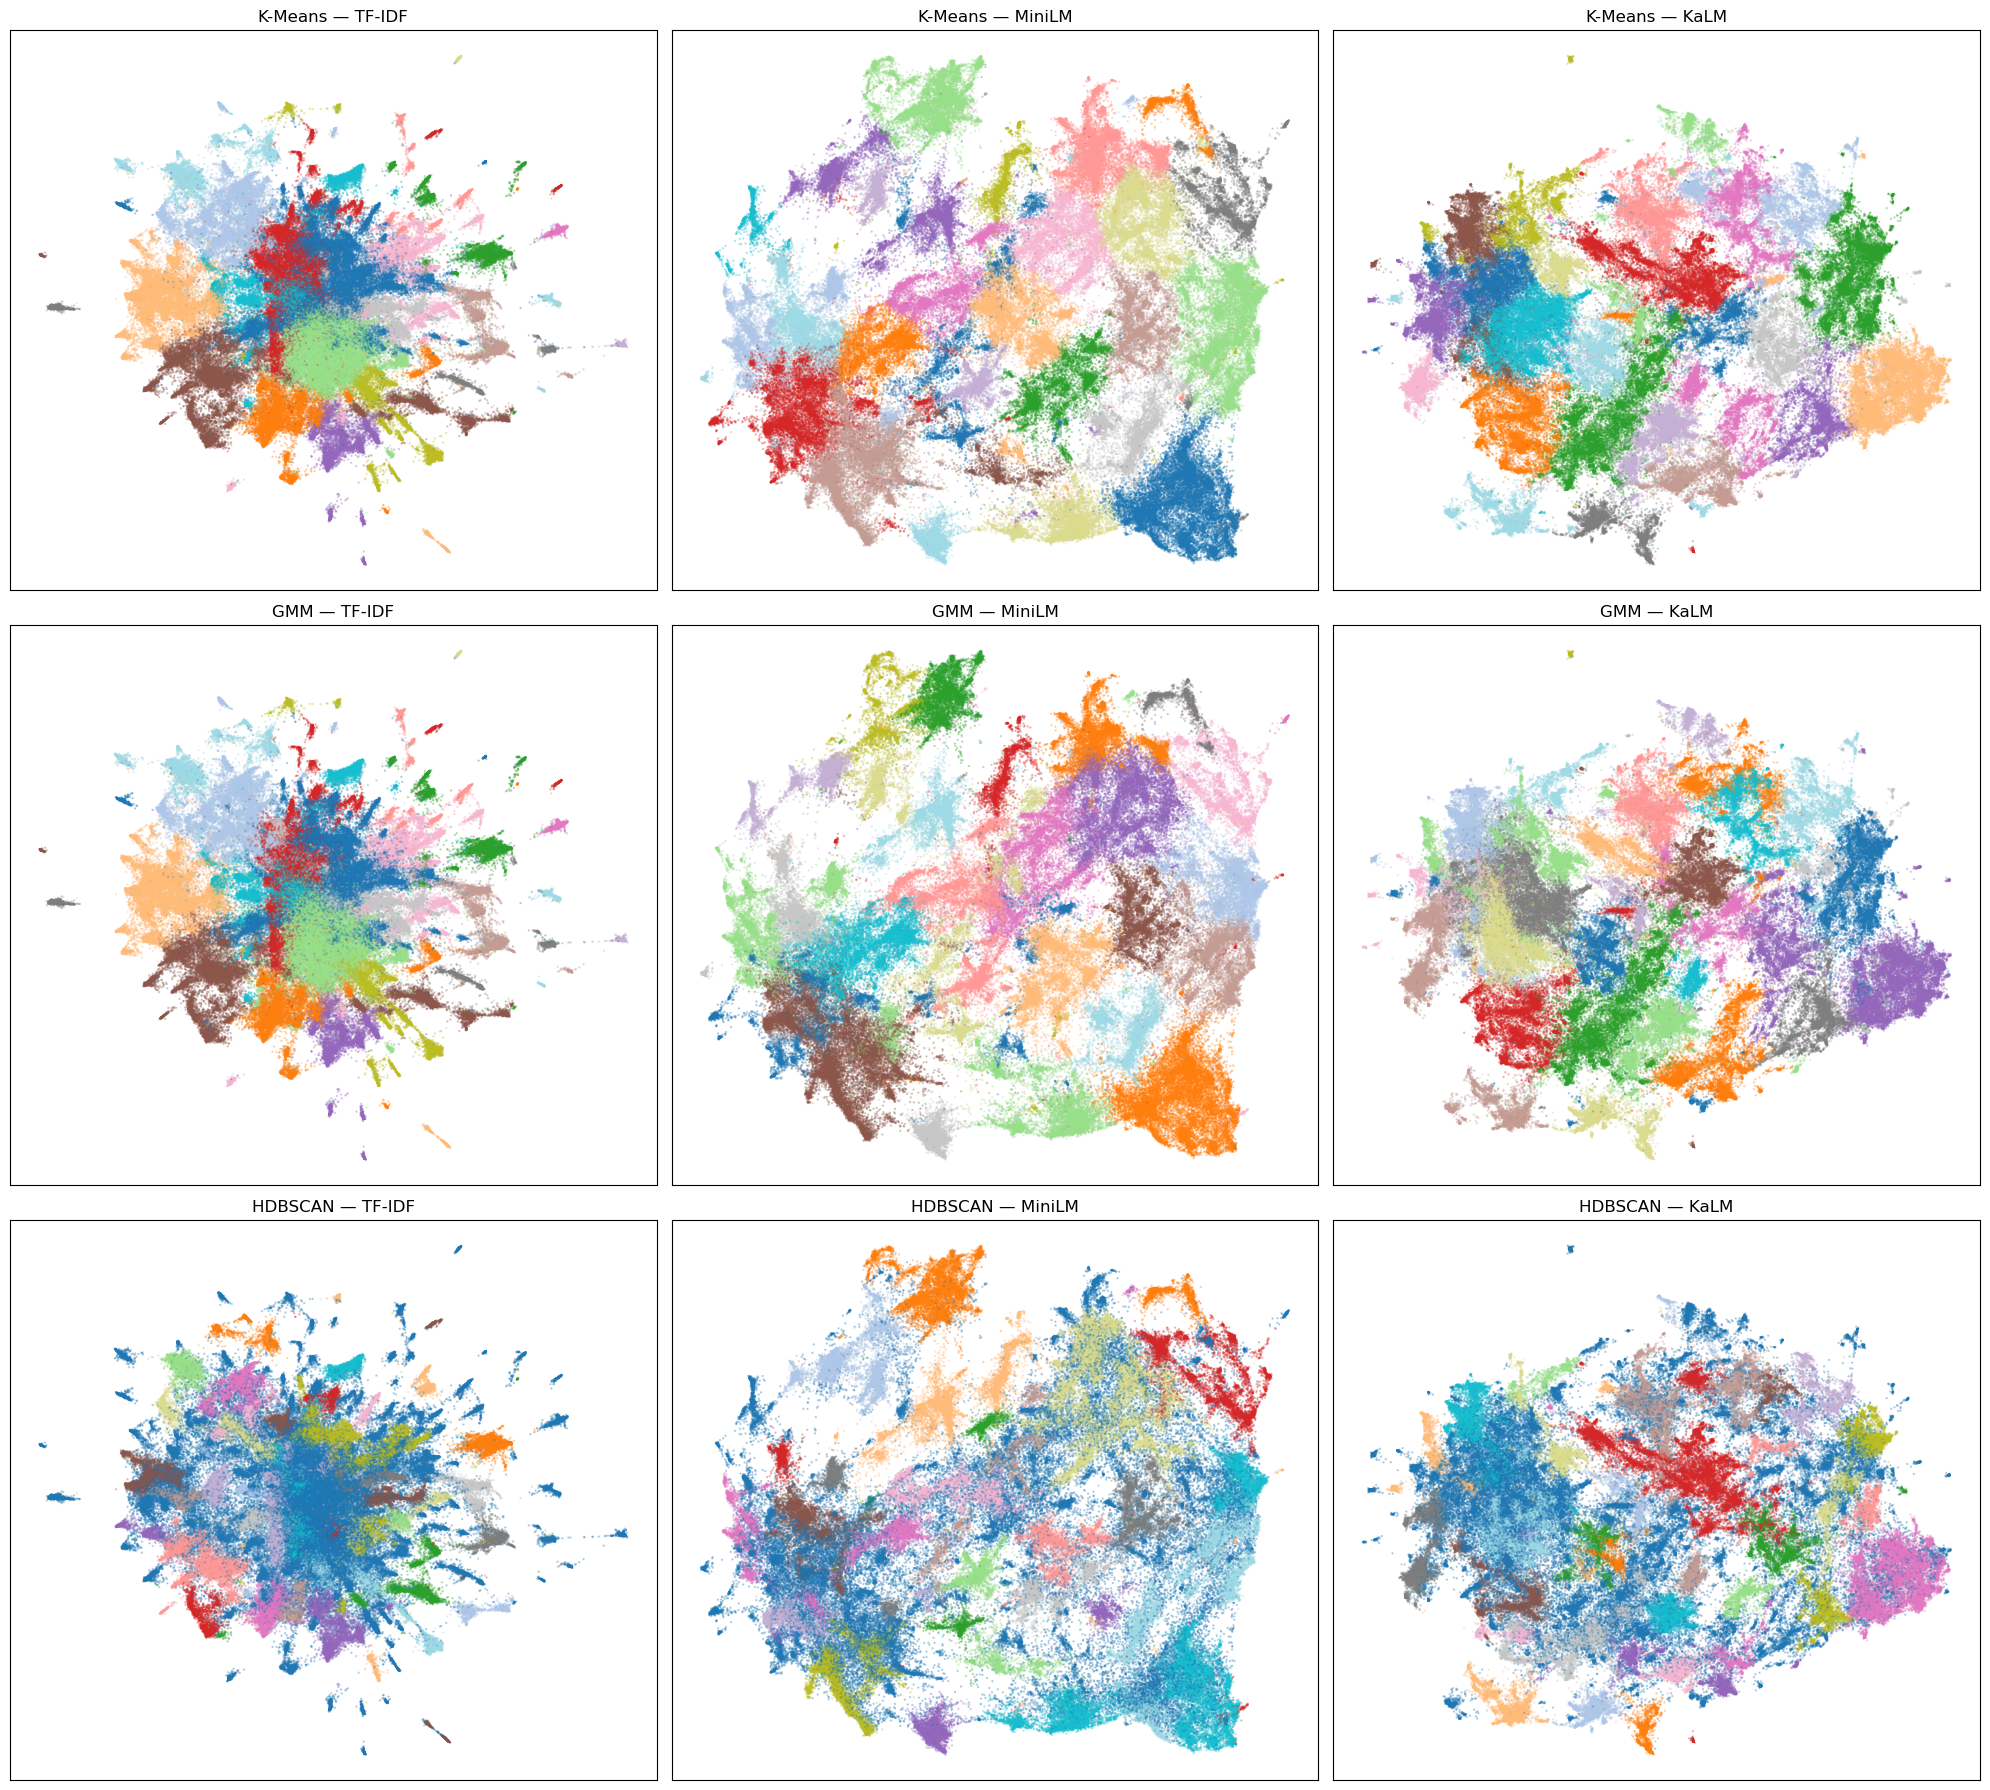

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for col, name in enumerate(embeddings):
    for row, (algo, labels) in enumerate(
        [
            ("K-Means", kmeans_labels[name]),
            ("GMM", gmm_labels[name]),
            ("HDBSCAN", hdbscan_labels[name]),
        ]
    ):
        ax = axes[row, col]
        colors = labels.copy().astype(float)
        if -1 in set(labels):
            colors[labels == -1] = -1
        ax.scatter(
            viz_2d[name][:, 0],
            viz_2d[name][:, 1],
            c=colors,
            cmap="tab20",
            s=0.5,
            alpha=0.3,
        )
        ax.set_title(f"{algo} — {name}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
fig.savefig(figures_dir / "cluster_scatter_3x3.png", dpi=300, bbox_inches="tight")
plt.show()

 ## Full Comparison (9 Combinations)

In [6]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
)

best_k = {"TF-IDF": 23, "MiniLM": 28, "KaLM": 26}
gmm_best_k = {"TF-IDF": 23, "MiniLM": 29, "KaLM": 28}

all_results = []

for name, data in embeddings.items():
    labels = kmeans_labels[name]
    all_results.append(
        {
            "Embedding": name,
            "Algorithm": "K-Means",
            "k": best_k[name],
            "Silhouette": silhouette_score(data, labels, sample_size=10000),
            "Davies-Bouldin": davies_bouldin_score(data, labels),
            "Calinski-Harabasz": calinski_harabasz_score(data, labels),
            "Noise %": 0.0,
        }
    )

    labels = gmm_labels[name]
    all_results.append(
        {
            "Embedding": name,
            "Algorithm": "GMM",
            "k": gmm_best_k[name],
            "Silhouette": silhouette_score(data, labels, sample_size=10000),
            "Davies-Bouldin": davies_bouldin_score(data, labels),
            "Calinski-Harabasz": calinski_harabasz_score(data, labels),
            "Noise %": 0.0,
        }
    )

    labels = hdbscan_labels[name]
    mask = labels != -1
    all_results.append(
        {
            "Embedding": name,
            "Algorithm": "HDBSCAN",
            "k": len(set(labels[mask])),
            "Silhouette": silhouette_score(data[mask], labels[mask], sample_size=10000),
            "Davies-Bouldin": davies_bouldin_score(data[mask], labels[mask]),
            "Calinski-Harabasz": calinski_harabasz_score(data[mask], labels[mask]),
            "Noise %": (labels == -1).mean() * 100,
        }
    )

comparison = pd.DataFrame(all_results).round(4)
print(comparison.to_string(index=False))

Embedding Algorithm  k  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise %
   TF-IDF   K-Means 23      0.3268          0.9826         32462.5941   0.0000
   TF-IDF       GMM 23      0.3124          1.0134         31101.2203   0.0000
   TF-IDF   HDBSCAN 42      0.5246          0.7073         41362.6150  46.0109
   MiniLM   K-Means 28      0.4259          0.8068        105179.4069   0.0000
   MiniLM       GMM 29      0.3563          0.9536         84718.1406   0.0000
   MiniLM   HDBSCAN 40      0.4398          0.7450         63038.9832  32.9559
     KaLM   K-Means 26      0.3930          0.9374         76525.6326   0.0000
     KaLM       GMM 28      0.3281          1.1853         65292.5577   0.0000
     KaLM   HDBSCAN 39      0.4927          0.7217         47171.3249  35.6598


### Metric Comparison Charts

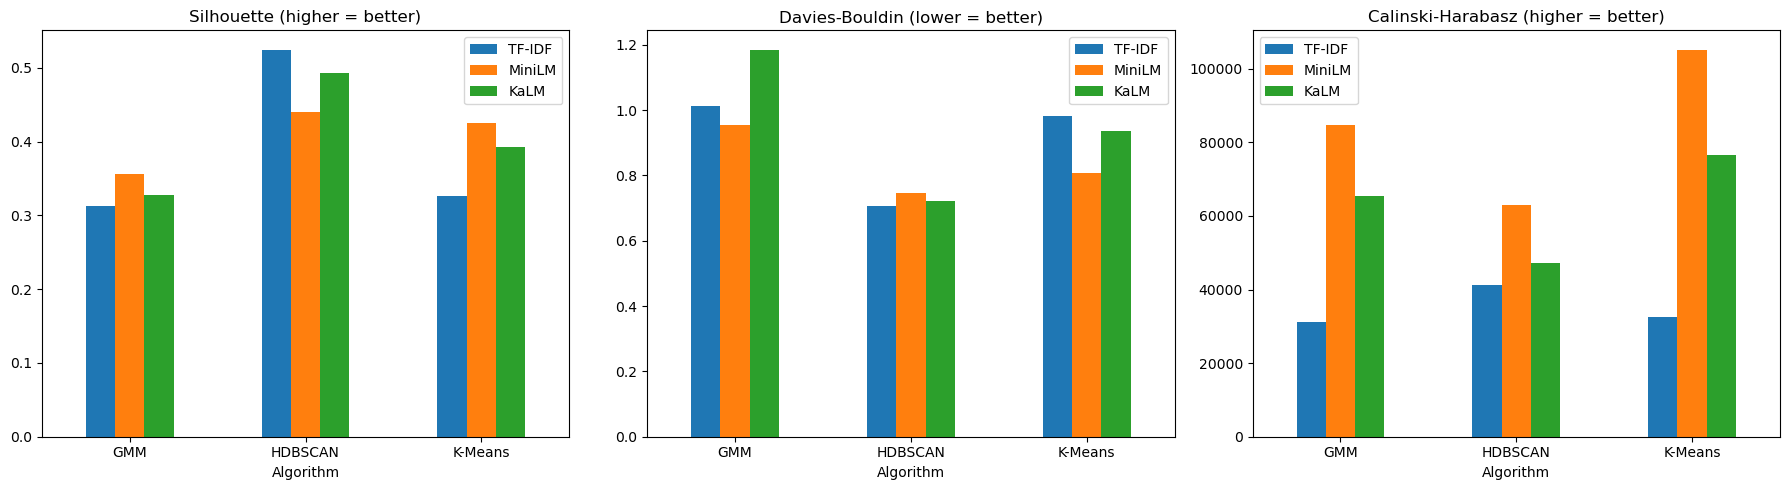

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
titles = [
    "Silhouette (higher = better)",
    "Davies-Bouldin (lower = better)",
    "Calinski-Harabasz (higher = better)",
]

for ax, metric, title in zip(axes, metrics, titles):
    pivot = comparison.pivot(index="Algorithm", columns="Embedding", values=metric)
    pivot = pivot[["TF-IDF", "MiniLM", "KaLM"]]
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
    ax.legend(title="")

plt.tight_layout()
fig.savefig(figures_dir / "metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

 ## Topic Coherence (c_v)

  Measures how often the top terms in each cluster co-occur in the corpus. Higher = more coherent topics.

In [8]:
from src.features import compute_coherence

coherence_results = []

for name in embeddings:
    for algo, labels in [
        ("K-Means", kmeans_labels[name]),
        ("GMM", gmm_labels[name]),
        ("HDBSCAN", hdbscan_labels[name]),
    ]:
        score = compute_coherence(df, labels, text_col="abstract")
        coherence_results.append(
            {
                "Embedding": name,
                "Algorithm": algo,
                "Coherence (c_v)": round(score, 4),
            }
        )
        print(f"{name} + {algo}: {score:.4f}")

coherence_df = pd.DataFrame(coherence_results)
print("\n")
print(coherence_df.to_string(index=False))

TF-IDF + K-Means: 0.4322
TF-IDF + GMM: 0.4301
TF-IDF + HDBSCAN: 0.4699
MiniLM + K-Means: 0.4354
MiniLM + GMM: 0.4336
MiniLM + HDBSCAN: 0.4585
KaLM + K-Means: 0.4356
KaLM + GMM: 0.4264
KaLM + HDBSCAN: 0.4464


Embedding Algorithm  Coherence (c_v)
   TF-IDF   K-Means           0.4322
   TF-IDF       GMM           0.4301
   TF-IDF   HDBSCAN           0.4699
   MiniLM   K-Means           0.4354
   MiniLM       GMM           0.4336
   MiniLM   HDBSCAN           0.4585
     KaLM   K-Means           0.4356
     KaLM       GMM           0.4264
     KaLM   HDBSCAN           0.4464


## Cluster Labeling

  Two approaches:
  1. **TF-IDF top terms** — reproducible, no API needed
  2. **Claude Opus labels** — richer, human-readable

In [9]:
from src.features import get_cluster_top_terms

best_hdbscan = hdbscan_labels["KaLM"]

hdbscan_terms = get_cluster_top_terms(df, best_hdbscan, text_col="abstract")

print(f"Labeled {len(hdbscan_terms)} clusters\n")
for label, terms in hdbscan_terms.items():
    n_papers = (best_hdbscan == label).sum()
    term_str = ", ".join(t[0] for t in terms[:7])
    print(f"Cluster {label} ({n_papers:,} papers): {term_str}")

Labeled 39 clusters

Cluster 0 (1,629 papers): deepfake, detection, face, forgery, images, models, image
Cluster 1 (2,019 papers): adversarial, models, attacks, model, attack, robustness, image
Cluster 2 (2,734 papers): graph, learning, graphs, node, gnns, data, networks
Cluster 3 (1,837 papers): molecular, models, protein, model, data, drug, learning
Cluster 4 (1,338 papers): causal, data, models, model, counterfactual, learning, methods
Cluster 5 (4,348 papers): data, learning, model, fl, privacy, federated, models
Cluster 6 (2,363 papers): models, llms, language, hallucinations, hallucination, model, large
Cluster 7 (3,406 papers): data, model, models, learning, based, images, image
Cluster 8 (1,819 papers): models, model, explanations, methods, based, feature, interpretability
Cluster 9 (1,030 papers): emotion, sentiment, emotional, models, model, emotions, analysis
Cluster 10 (1,769 papers): anomaly, detection, data, based, model, anomalies, methods
Cluster 11 (13,129 papers): mod

In [10]:
best_kmeans = kmeans_labels["KaLM"]

kmeans_terms = get_cluster_top_terms(df, best_kmeans, text_col="abstract")

print(f"Labeled {len(kmeans_terms)} clusters\n")
for label, terms in kmeans_terms.items():
    n_papers = (best_kmeans == label).sum()
    term_str = ", ".join(t[0] for t in terms[:7])
    print(f"Cluster {label} ({n_papers:,} papers): {term_str}")

Labeled 26 clusters

Cluster 0 (9,382 papers): models, llms, language, model, large, llm, human
Cluster 1 (3,586 papers): domain, data, segmentation, model, models, methods, performance
Cluster 2 (7,392 papers): video, models, model, motion, based, temporal, generation
Cluster 3 (9,955 papers): models, model, training, performance, language, attention, large
Cluster 4 (14,474 papers): robot, based, real, learning, control, model, tasks
Cluster 5 (12,328 papers): 3d, based, methods, model, method, view, point
Cluster 6 (12,142 papers): learning, data, model, training, neural, models, performance
Cluster 7 (3,833 papers): models, adversarial, model, image, attacks, images, based
Cluster 8 (10,643 papers): models, data, model, medical, clinical, learning, based
Cluster 9 (7,734 papers): models, visual, language, image, multimodal, model, reasoning
Cluster 10 (5,454 papers): driving, data, model, traffic, based, autonomous, models
Cluster 11 (6,167 papers): retrieval, models, knowledge, ll

 ### Claude Opus Labels

In [11]:
import os

from dotenv import load_dotenv

load_dotenv(project_root / ".env")
print(f"API key loaded: {'ANTHROPIC_API_KEY' in os.environ}")

API key loaded: True


In [13]:
from src.label import label_clusters, save_labels

hdbscan_claude = label_clusters(df, best_hdbscan, n_samples=20)
save_labels(hdbscan_claude, processed_dir / "hdbscan_kalm_labels.json")

2026-04-22 14:14:00,367 - INFO - Labeling 39 clusters with Claude Opus
2026-04-22 14:14:05,004 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:14:05,010 - INFO -   [1/39] Cluster 0 (1,629 papers): Face Image Forensics and Security
2026-04-22 14:14:10,414 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:14:10,415 - INFO -   [2/39] Cluster 1 (2,019 papers): Adversarial Attacks and Robustness
2026-04-22 14:14:16,777 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:14:16,779 - INFO -   [3/39] Cluster 2 (2,734 papers): Graph Neural Networks Research
2026-04-22 14:14:22,307 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:14:22,308 - INFO -   [4/39] Cluster 3 (1,837 papers): AI for Molecular and Biological Sciences
2026-04-22 14:14:28,350 - INFO - HTTP Request: POST https://api.anthropic.com/v1/mes

In [14]:
kmeans_claude = label_clusters(df, best_kmeans, n_samples=20)
save_labels(kmeans_claude, processed_dir / "kmeans_kalm_labels.json")

2026-04-22 14:22:01,540 - INFO - Labeling 26 clusters with Claude Opus
2026-04-22 14:22:05,981 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:22:05,986 - INFO -   [1/26] Cluster 0 (9,382 papers): LLM Evaluation, Benchmarking & Applications
2026-04-22 14:22:11,101 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:22:11,106 - INFO -   [2/26] Cluster 1 (3,586 papers): Domain Adaptation and Generalization Methods
2026-04-22 14:22:16,243 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:22:16,249 - INFO -   [3/26] Cluster 2 (7,392 papers): Multimodal Video and Human Understanding
2026-04-22 14:22:22,365 - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
2026-04-22 14:22:22,370 - INFO -   [4/26] Cluster 3 (9,955 papers): Efficient Transformer Model Optimization
2026-04-22 14:22:28,099 - INFO - HTTP Request: POST ht

## Cluster Size Distribution

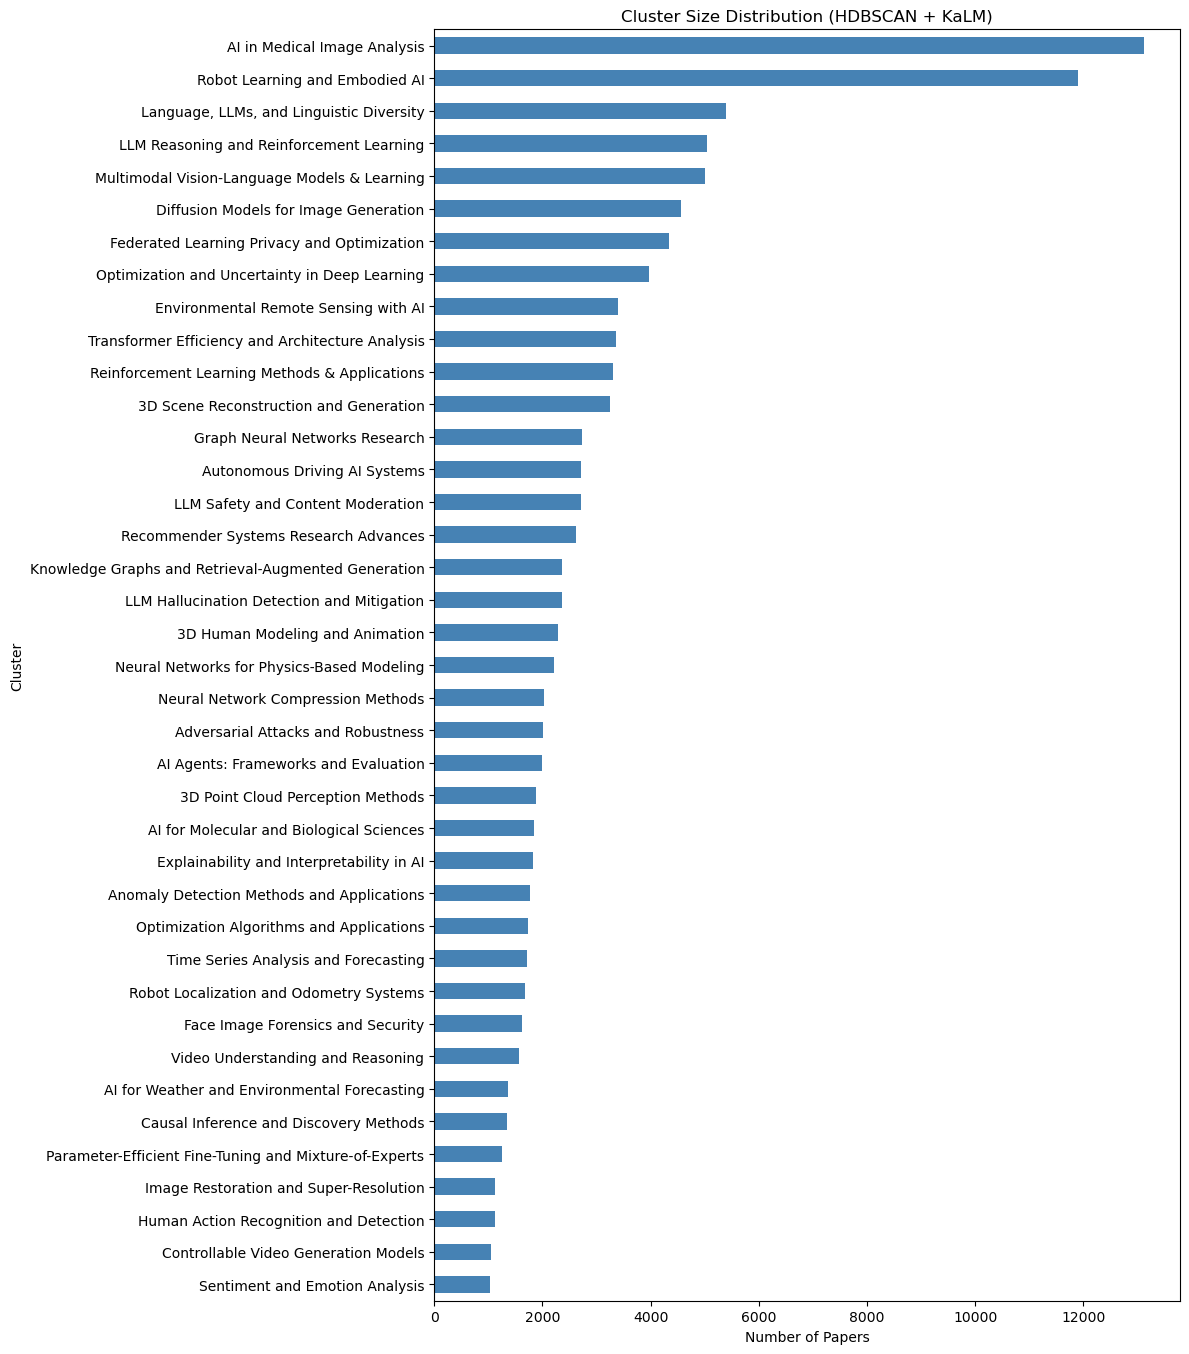

In [15]:
from src.label import load_labels

label_info = load_labels(processed_dir / "hdbscan_kalm_labels.json")

cluster_names = []
cluster_sizes = []
for label in sorted(label_info.keys()):
    cluster_names.append(label_info[label]["label"])
    cluster_sizes.append((best_hdbscan == label).sum())

size_df = pd.DataFrame(
    {
        "Cluster": cluster_names,
        "Papers": cluster_sizes,
    }
).sort_values("Papers", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(8, len(size_df) * 0.35)))
size_df.plot(
    kind="barh",
    x="Cluster",
    y="Papers",
    ax=ax,
    color="steelblue",
    legend=False,
)
ax.set_xlabel("Number of Papers")
ax.set_title("Cluster Size Distribution (HDBSCAN + KaLM)")
plt.tight_layout()
fig.savefig(figures_dir / "cluster_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

  ## Top Terms per Cluster

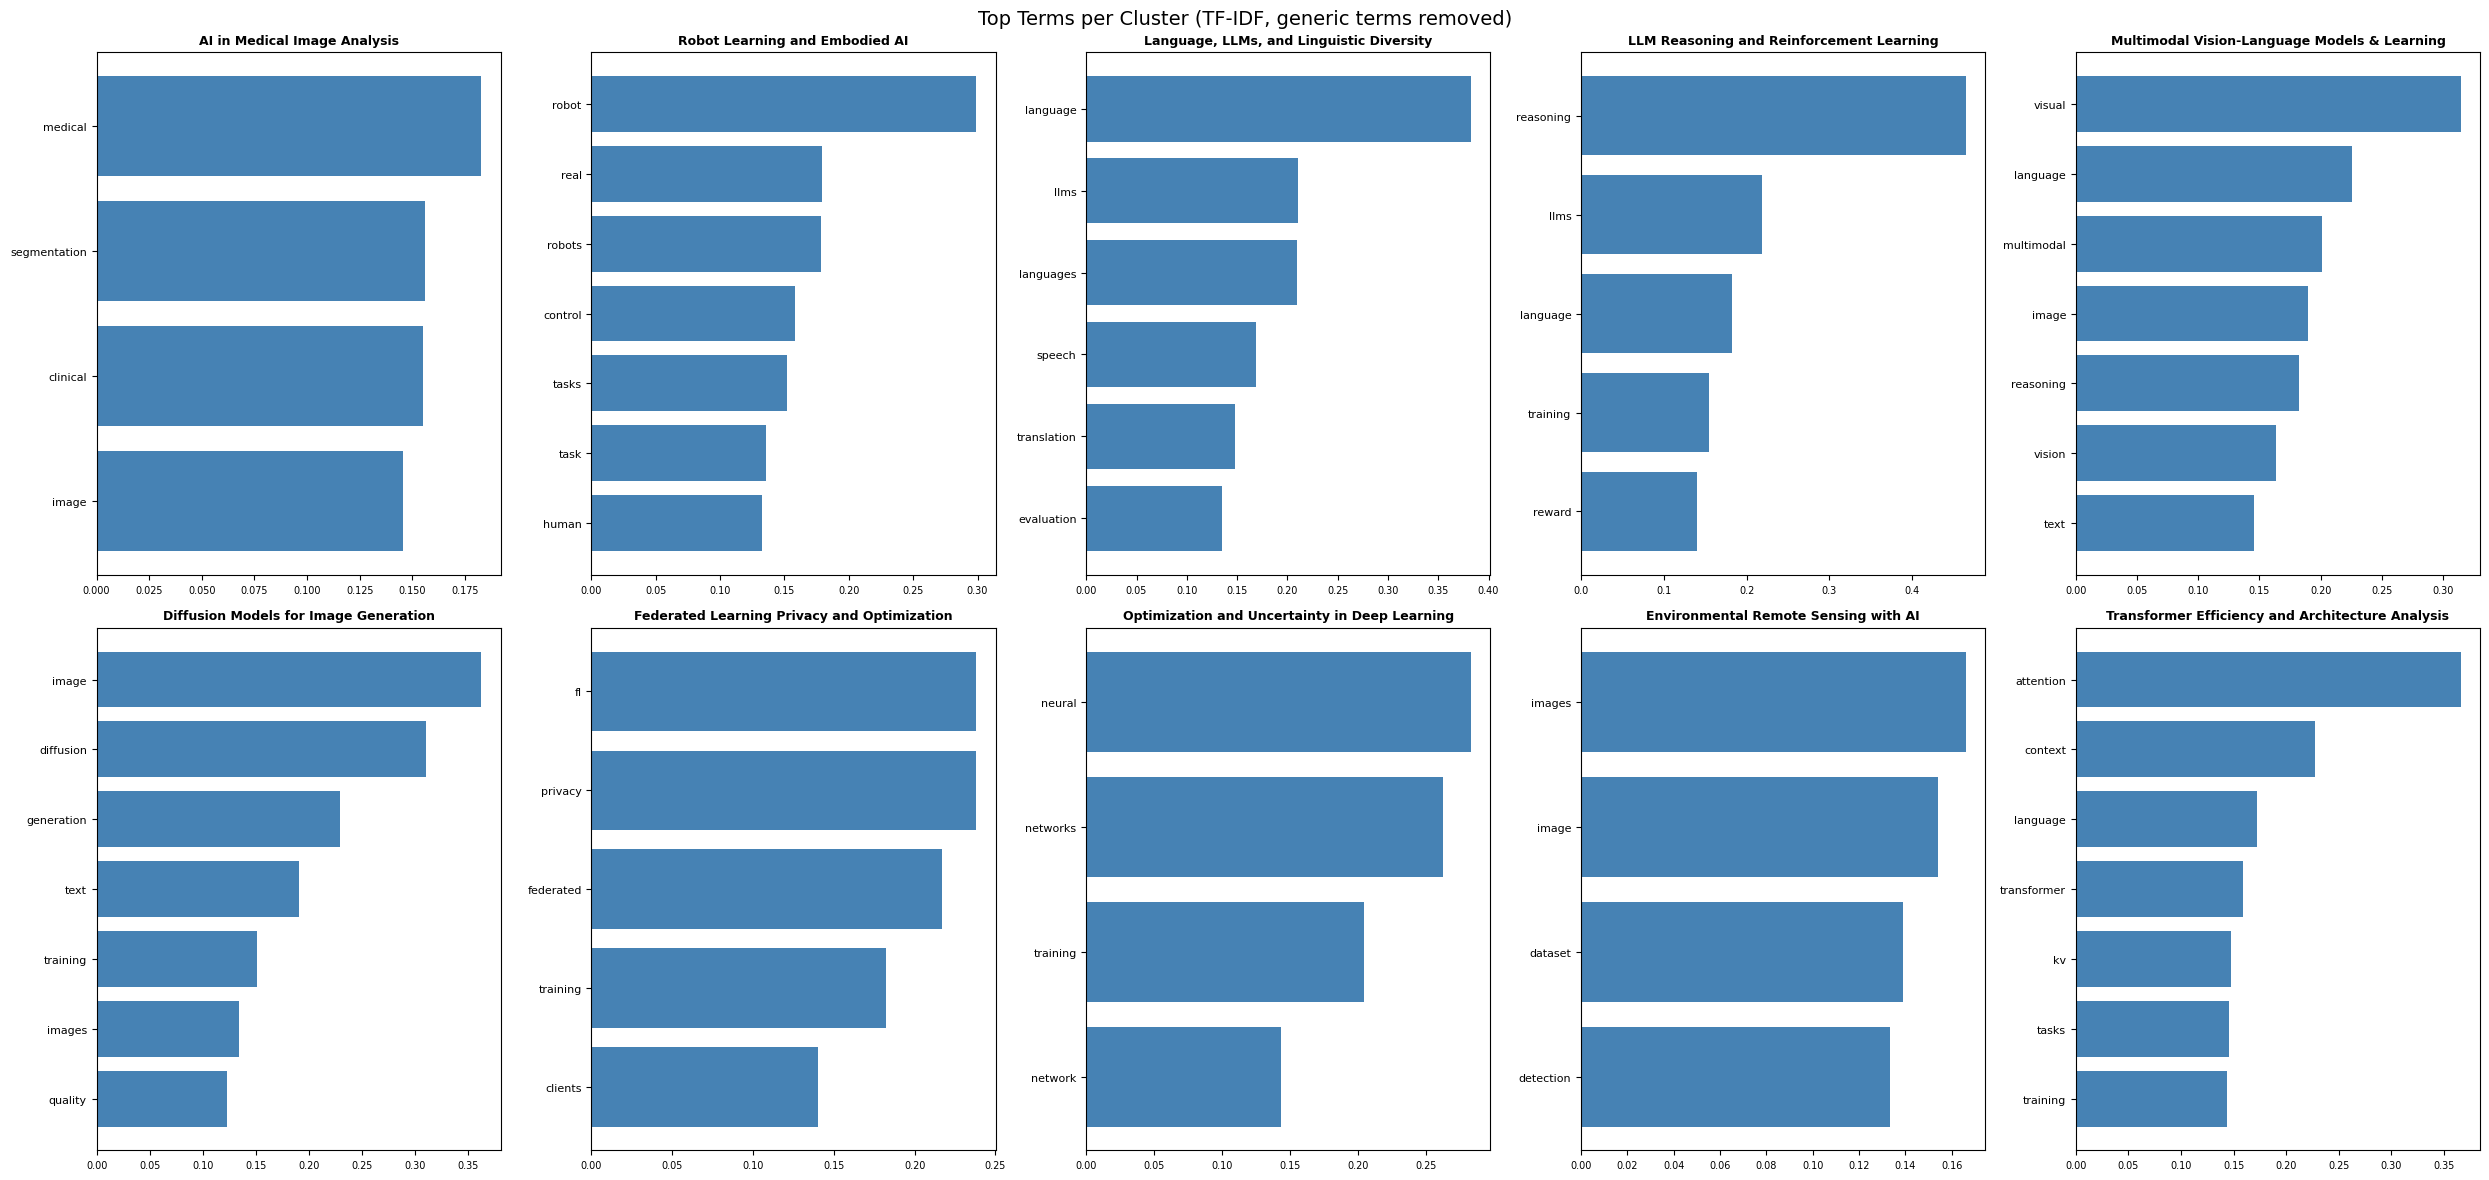

In [16]:
STOPWORDS = {
    "model",
    "models",
    "based",
    "data",
    "learning",
    "methods",
    "method",
    "performance",
    "proposed",
    "approach",
    "using",
    "paper",
    "results",
    "large",
}

top_clusters = (
    size_df.sort_values("Papers", ascending=False).head(10)["Cluster"].tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

for ax, cluster_name in zip(axes, top_clusters):
    label_id = [k for k, v in label_info.items() if v["label"] == cluster_name][0]
    terms = hdbscan_terms[label_id]
    filtered = [(t[0], t[1]) for t in terms if t[0] not in STOPWORDS][:8]

    words = [t[0] for t in filtered][::-1]
    scores = [t[1] for t in filtered][::-1]

    ax.barh(words, scores, color="steelblue")
    ax.set_title(cluster_name, fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle(
    "Top Terms per Cluster (TF-IDF, generic terms removed)",
    fontsize=14,
)
plt.tight_layout()
fig.savefig(figures_dir / "top_terms_per_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

## Hierarchical Topic Structure

  Ward linkage on cluster centroids shows which topics are most similar.

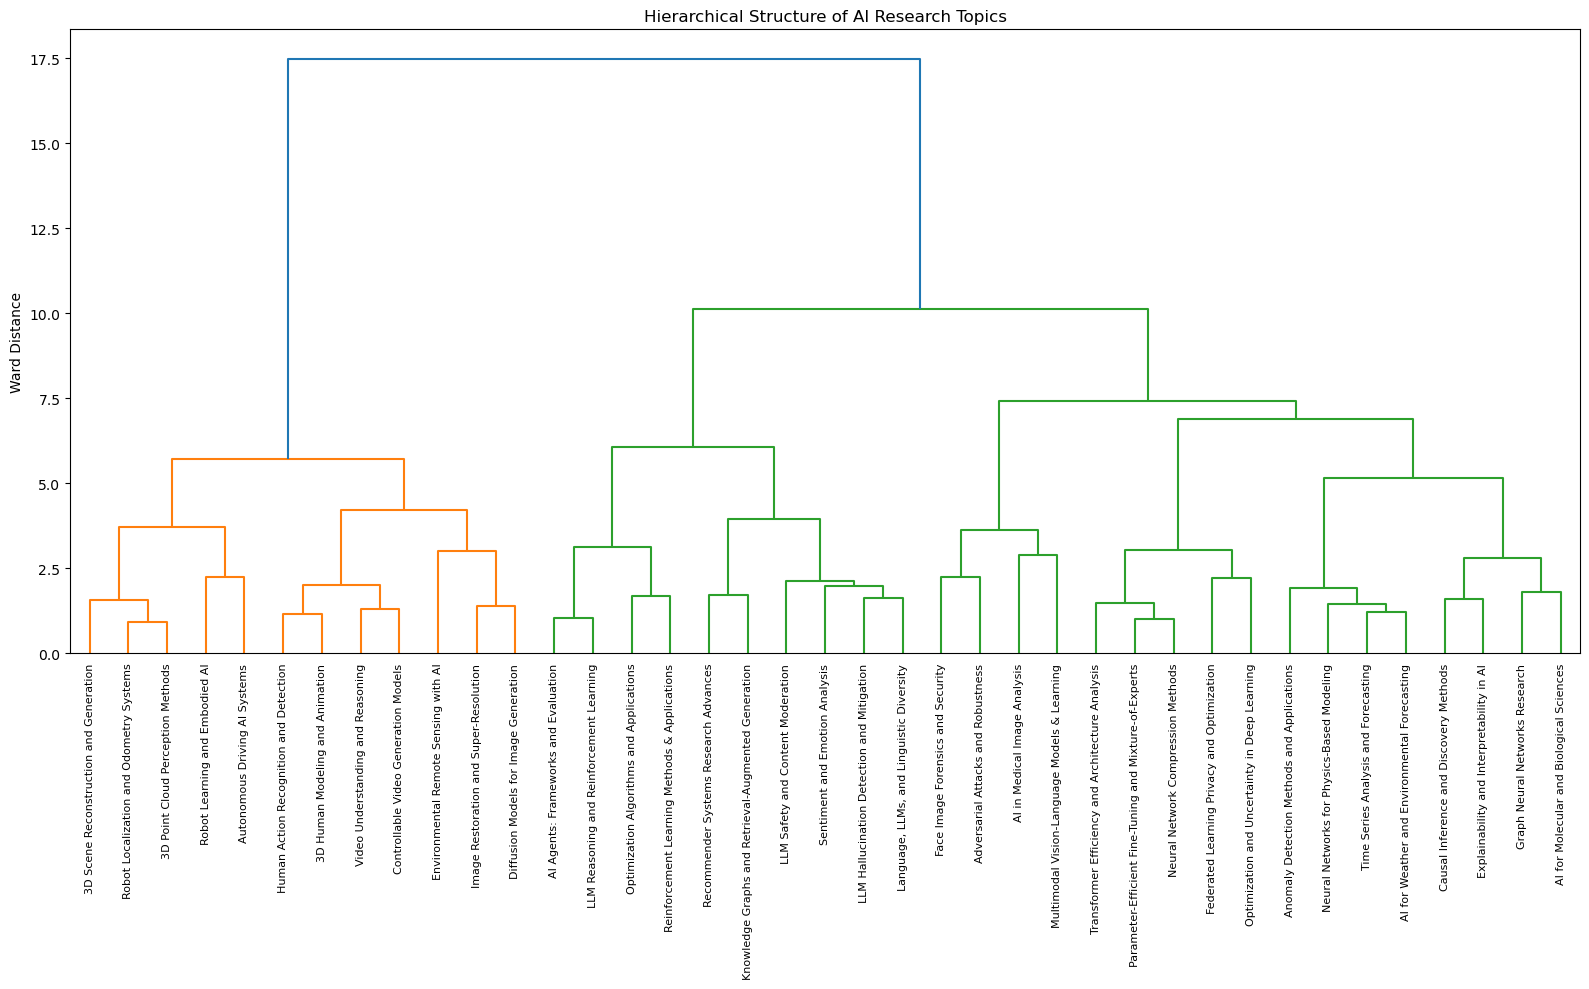

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

centroids = []
centroid_names = []
for label in sorted(label_info.keys()):
    mask = best_hdbscan == label
    if mask.sum() == 0:
        continue
    centroids.append(kalm_cluster[mask].mean(axis=0))
    centroid_names.append(label_info[label]["label"])

centroids = np.array(centroids)
Z = linkage(centroids, method="ward")

fig, ax = plt.subplots(figsize=(16, 10))
dendrogram(
    Z,
    labels=centroid_names,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
)
ax.set_title("Hierarchical Structure of AI Research Topics")
ax.set_ylabel("Ward Distance")
plt.tight_layout()
fig.savefig(figures_dir / "dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**9 combinations tested:** 3 embeddings (TF-IDF, MiniLM, KaLM) × 3 algorithms (K-Means, GMM, HDBSCAN)

### Complete Comparison Table

```
Embedding   Algorithm  k    Silhouette  Davies-Bouldin  Calinski-Harabasz  Coherence  Noise %
TF-IDF      K-Means    23   0.3268      0.9826          32,463             0.4322     0.0
TF-IDF      GMM        23   0.3124      1.0134          31,101             0.4301     0.0
TF-IDF      HDBSCAN    42   0.5246      0.7073          41,363             0.4699     46.0
MiniLM      K-Means    28   0.4259      0.8068          105,179            0.4354     0.0
MiniLM      GMM        29   0.3563      0.9536          84,718             0.4336     0.0
MiniLM      HDBSCAN    40   0.4398      0.7450          63,039             0.4585     33.0
KaLM        K-Means    26   0.3930      0.9374          76,526             0.4356     0.0
KaLM        GMM        28   0.3281      1.1853          65,293             0.4264     0.0
KaLM        HDBSCAN    39   0.4927      0.7217          47,171             0.4464     35.7   <- PRIMARY
```

### Primary: KaLM + HDBSCAN (min_cluster_size=1000)

- 39 clusters, 35.7% noise, silhouette 0.4927, Davies-Bouldin 0.7217
- Fine-grained topics separating LLM research into distinct sub-communities (Reasoning, Agents, Safety, Hallucination, RAG, etc.)

### Secondary: KaLM + K-Means (k=26)

- 26 clusters, 0% noise, silhouette 0.3930
- Broader topic groupings for complete coverage

### Key findings

- HDBSCAN consistently outperforms K-Means and GMM on silhouette and Davies-Bouldin across all embeddings
- GMM consistently worst — Gaussian assumptions don't fit research topic distributions
- TF-IDF + HDBSCAN has highest silhouette (0.525) but 46% noise is too aggressive to be useful
- Topic coherence (c_v) highest for HDBSCAN across all embeddings
- Neural embeddings (MiniLM, KaLM) produce much higher Calinski-Harabasz than TF-IDF

### Largest clusters (HDBSCAN + KaLM)

- AI in Medical Image Analysis (13,129 papers)
- Robot Learning and Embodied AI (11,898 papers)
- Language, LLMs, and Linguistic Diversity (5,388 papers)
- LLM Reasoning and Reinforcement Learning (5,037 papers)
- Multimodal Vision-Language Models & Learning (4,998 papers)

All cluster labels and embeddings saved to `data/processed/`.